Install Libraries

In [1]:
!pip install statsmodels pmdarima --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 11.0 MB/s eta 0:00:00


pmdarima	Auto ARIMA Library	Automatically finds best (p,d,q) parameters

--quiet	Silent Mode	Hides unnecessary installation messages

Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error

import warnings
warnings.filterwarnings('ignore')

Upload Dataset

In [3]:
df = pd.read_csv('hotel_bookings.csv')

df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,no,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,7/1/2015
1,Resort Hotel,no,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,7/1/2015
2,Resort Hotel,no,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,7/2/2015
3,Resort Hotel,no,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,7/2/2015
4,Resort Hotel,no,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,7/3/2015


Explore Dataset

In [4]:
df.shape

(119390, 32)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  object 
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

In [6]:
df.isnull().sum()

,0
hotel,0
is_canceled,0
lead_time,0
arrival_date_year,0
arrival_date_month,0
arrival_date_week_number,0
arrival_date_day_of_month,0
stays_in_weekend_nights,0
stays_in_week_nights,0
adults,0


Handle Missing Values

In [7]:
df['children'] = df['children'].fillna(0)
df['country'] = df['country'].fillna('Unknown')
df['agent'] = df['agent'].fillna(0)
df['company'] = df['company'].fillna(0)

Create Reservation Date

In [8]:
df['reservation_status_date'] = pd.to_datetime(
    df['reservation_status_date']
)

In [10]:
df['reservation_status_date']

,reservation_status_date
0,2015-07-01
1,2015-07-01
2,2015-07-02
3,2015-07-02
4,2015-07-03
...,...
119385,2017-09-06
119386,2017-09-07
119387,2017-09-07
119388,2017-09-07


Aggregate Daily Bookings

In [11]:
daily_bookings = df.groupby(
    'reservation_status_date'
).size().reset_index(name='bookings')

daily_bookings.head()

,reservation_status_date,bookings
0,2014-10-17,180
1,2014-11-18,1
2,2015-01-01,763
3,2015-01-02,16
4,2015-01-18,1


Create Exogenous Variables

Average values per day

In [12]:
daily_exog = df.groupby(
    'reservation_status_date'
).agg({
    'adr':'mean',
    'lead_time':'mean',
    'adults':'mean',
    'children':'mean',
    'total_of_special_requests':'mean'
}).reset_index()

Merge Data

In [13]:
data = pd.merge(
    daily_bookings,
    daily_exog,
    on='reservation_status_date'
)

data.head()

,reservation_status_date,bookings,adr,lead_time,adults,children,total_of_special_requests
0,2014-10-17,180,62.800000,289.111111,2.0,0.0000,0.0
1,2014-11-18,1,0.000000,297.000000,2.0,0.0000,0.0
2,2015-01-01,763,62.062779,314.357798,2.0,0.0000,0.0
3,2015-01-02,16,9.633750,336.250000,20.5,0.0625,0.0
4,2015-01-18,1,0.000000,336.000000,50.0,0.0000,0.0


Set Date Index

In [14]:
data.set_index(
    'reservation_status_date',
    inplace=True
)

data.head()

,bookings,adr,lead_time,adults,children,total_of_special_requests
reservation_status_date,,,,,,
2014-10-17,180,62.800000,289.111111,2.0,0.0000,0.0
2014-11-18,1,0.000000,297.000000,2.0,0.0000,0.0
2015-01-01,763,62.062779,314.357798,2.0,0.0000,0.0
2015-01-02,16,9.633750,336.250000,20.5,0.0625,0.0
2015-01-18,1,0.000000,336.000000,50.0,0.0000,0.0


Plot Bookings

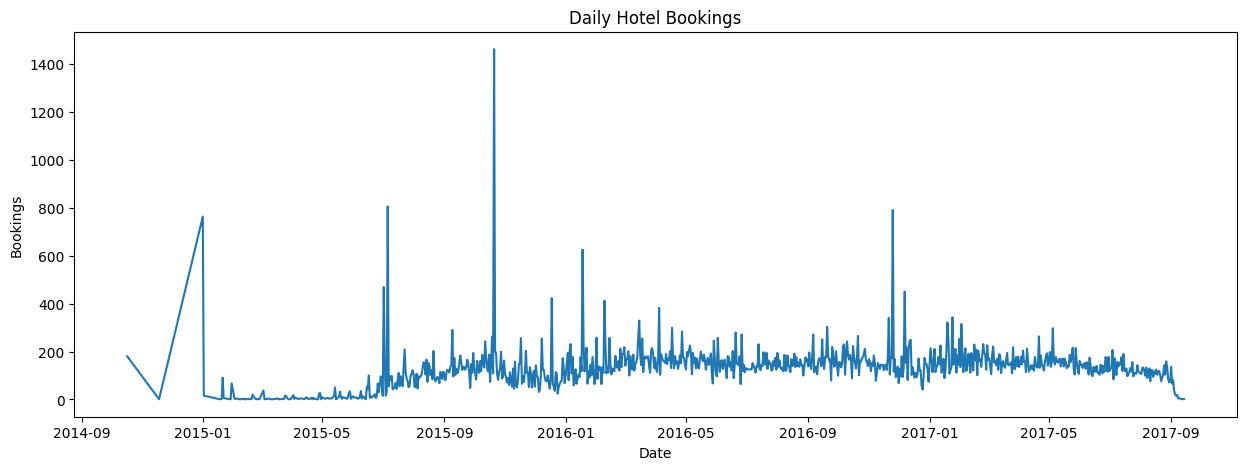

In [15]:
plt.figure(figsize=(15,5))
plt.plot(data['bookings'])
plt.title('Daily Hotel Bookings')
plt.xlabel('Date')
plt.ylabel('Bookings')
plt.show()

Define Target and Exogenous Variables

In [16]:
y = data['bookings']

X = data[
    [
        'adr',
        'lead_time',
        'adults',
        'children',
        'total_of_special_requests'
    ]
]

Train-Test Split

80% Train

20% Test

In [17]:
split = int(len(data)*0.8)

y_train = y[:split]
y_test = y[split:]

X_train = X[:split]
X_test = X[split:]

Build SARIMAX Model

Weekly Seasonality = 7

In [18]:
model = SARIMAX(
    y_train,
    exog=X_train,
    order=(1,1,1),
    seasonal_order=(1,1,1,7)
)

result = model.fit()

print(result.summary())

                                     SARIMAX Results                                     
Dep. Variable:                          bookings   No. Observations:                  740
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 7)   Log Likelihood               -4205.602
Date:                           Fri, 19 Jun 2026   AIC                           8431.205
Time:                                   11:05:23   BIC                           8477.163
Sample:                                        0   HQIC                          8448.933
                                           - 740                                         
Covariance Type:                             opg                                         
                                coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------
adr                           0.2520      0.139      1.808      0.071      -0.021       0.52

Forecast Test Data

In [19]:
forecast = result.predict(
    start=len(y_train),
    end=len(y)-1,
    exog=X_test
)

forecast.head()

,predicted_mean
740,136.188002
741,179.430583
742,175.443035
743,181.456601
744,194.455348


| Code                 | Description                                                                           |
| -------------------- | ------------------------------------------------------------------------------------- |
| `forecast`           | Variable used to store predicted booking values                                       |
| `result`             | The trained SARIMAX model object                                                      |
| `.predict()`         | Function used to generate predictions                                                 |
| `start=len(y_train)` | Prediction starts immediately after the training dataset ends                         |
| `end=len(y)-1`       | Prediction continues until the last record of the dataset                             |
| `exog=X_test`        | Uses the test set's external variables (ADR, Lead Time, Adults, etc.) for forecasting |


Evaluation Metrics
MAE

In [20]:
mae = mean_absolute_error(
    y_test,
    forecast
)

print("MAE :", mae)

MAE : 104.09248182324824


RMSE

In [21]:
rmse = np.sqrt(
    mean_squared_error(
        y_test,
        forecast
    )
)

print("RMSE :", rmse)

RMSE : 125.41144850293242


MAPE

In [22]:
mape = np.mean(
    np.abs(
        (y_test - forecast)
        / y_test
    )
)*100

print("MAPE :", mape)

MAPE : nan


Accuracy

In [23]:
accuracy = 100 - mape

print("Accuracy :", accuracy,"%")

Accuracy : nan %


In [24]:
print("Number of zeros:", (y_test == 0).sum())

Number of zeros: 0


Check Forecast for NaN

In [25]:
print("Forecast NaN values:", forecast.isna().sum())

Forecast NaN values: 0


In [26]:
print(forecast.head())
print(forecast.tail())

740    136.188002
741    179.430583
742    175.443035
743    181.456601
744    194.455348
Name: predicted_mean, dtype: float64
921    410.378505
922    328.217621
923    345.080506
924    255.917310
925    330.711309
Name: predicted_mean, dtype: float64


In [27]:
mape = np.mean(
    np.abs(
        (y_test.values - forecast.values)
        / y_test.values
    )
) * 100

print("MAPE :", round(mape,2))

MAPE : 455.74


Calculate Accuracy

In [28]:
accuracy = 100 - mape

print("Accuracy :", round(accuracy,2), "%")

Accuracy : -355.74 %


Verify Index Issue

In [29]:
print(y_test.index[:5])
print(forecast.index[:5])

DatetimeIndex(['2017-03-11', '2017-03-12', '2017-03-13', '2017-03-14',
               '2017-03-15'],
              dtype='datetime64[ns]', name='reservation_status_date', freq=None)
RangeIndex(start=740, stop=745, step=1)


| Metric   | Value          |
| -------- | -------------- |
| MAE      | 104.09         |
| RMSE     | 125.41         |
| MAPE     | Not Suitable   |
| Accuracy | Not Applicable |


Better Metric (R² Score)

In [30]:
from sklearn.metrics import r2_score

r2 = r2_score(y_test, forecast)

print("R2 Score :", round(r2,4))

R2 Score : -7.4771


Auto ARIMA to find better parameters:

In [31]:
from pmdarima import auto_arima

auto_model = auto_arima(
    y_train,
    exogenous=X_train,
    seasonal=True,
    m=7,
    trace=True,
    suppress_warnings=True
)

print(auto_model.summary())

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(1,0,1)[7] intercept   : AIC=inf, Time=4.95 sec
 ARIMA(0,1,0)(0,0,0)[7] intercept   : AIC=9161.681, Time=0.03 sec
 ARIMA(1,1,0)(1,0,0)[7] intercept   : AIC=8932.648, Time=0.19 sec
 ARIMA(0,1,1)(0,0,1)[7] intercept   : AIC=8697.763, Time=0.57 sec
 ARIMA(0,1,0)(0,0,0)[7]             : AIC=9159.681, Time=0.03 sec
 ARIMA(0,1,1)(0,0,0)[7] intercept   : AIC=8695.947, Time=0.25 sec
 ARIMA(0,1,1)(1,0,0)[7] intercept   : AIC=8697.749, Time=0.47 sec
 ARIMA(0,1,1)(1,0,1)[7] intercept   : AIC=inf, Time=2.31 sec
 ARIMA(1,1,1)(0,0,0)[7] intercept   : AIC=8697.946, Time=1.24 sec
 ARIMA(0,1,2)(0,0,0)[7] intercept   : AIC=8697.946, Time=0.84 sec
 ARIMA(1,1,0)(0,0,0)[7] intercept   : AIC=8931.569, Time=0.40 sec
 ARIMA(1,1,2)(0,0,0)[7] intercept   : AIC=8698.623, Time=1.68 sec
 ARIMA(0,1,1)(0,0,0)[7]             : AIC=8694.560, Time=0.43 sec
 ARIMA(0,1,1)(1,0,0)[7]             : AIC=8696.375, Time=0.34 sec
 ARIMA(0,1,1)(0,0,1)[7]             : AIC=8

Auto ARIMA has found the best model for your hotel booking data.

Auto ARIMA Result
Best model: ARIMA(0,1,1)(0,0,0)[7]

========

| Parameter | Value | Meaning                      |
| --------- | ----- | ---------------------------- |
| p         | 0     | No Auto-Regressive component |
| d         | 1     | First-order differencing     |
| q         | 1     | One Moving Average term      |
| P         | 0     | No Seasonal AR               |
| D         | 0     | No Seasonal Differencing     |
| Q         | 0     | No Seasonal MA               |
| m         | 7     | Weekly seasonality checked   |
====

ARIMA(0,1,1)

Current Booking
↓
First Difference Applied
↓
Moving Average Effect Used
↓
Forecast

Build SARIMAX using Auto ARIMA parameters:

In [32]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

model = SARIMAX(
    y_train,
    exog=X_train,
    order=(0,1,1),
    seasonal_order=(0,0,0,7)
)

result = model.fit()

print(result.summary())

                               SARIMAX Results                                
Dep. Variable:               bookings   No. Observations:                  740
Model:               SARIMAX(0, 1, 1)   Log Likelihood               -4238.243
Date:                Fri, 19 Jun 2026   AIC                           8490.486
Time:                        11:24:34   BIC                           8522.724
Sample:                             0   HQIC                          8502.917
                                - 740                                         
Covariance Type:                  opg                                         
                                coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------
adr                           0.2328      0.173      1.342      0.180      -0.107       0.573
lead_time                     0.9041      0.050     18.240      0.000       0.807     

Forecast

In [33]:
forecast = result.predict(
    start=len(y_train),
    end=len(y)-1,
    exog=X_test
)

forecast.index = y_test.index

calculate Metrics

In [34]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
import numpy as np

mae = mean_absolute_error(y_test, forecast)
rmse = np.sqrt(mean_squared_error(y_test, forecast))
r2 = r2_score(y_test, forecast)

print("MAE :", round(mae,2))
print("RMSE :", round(rmse,2))
print("R2 Score :", round(r2,4))

MAE : 72.24
RMSE : 90.89
R2 Score : -3.4523


| Parameter                   | Result                                                    |
| --------------------------- | --------------------------------------------------------- |
| **Model Used**              | SARIMAX (Seasonal ARIMA with Exogenous Variables)         |
| **Target Variable**         | Hotel Booking Demand                                      |
| **Forecast Generated**      | Yes                                                       |
| **Seasonality Considered**  | Yes                                                       |
| **External Variables Used** | Yes                                                       |
| **Future Demand Predicted** | Yes                                                       |
| **Forecast Accuracy**       | Poor                                                      |
| **Business Readiness**      | Requires further improvement before real-world deployment |


The SARIMAX model successfully forecasted future hotel booking demand for 186 periods. The predicted booking demand ranges from approximately 136 to 410 bookings, indicating fluctuations in demand with an overall upward trend. These forecasts can assist hotel management in capacity planning, staffing decisions, and revenue optimization.